In [45]:
# Librerias básicas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Librerias de Tensorflow/Keras
from keras.models import Sequential
from keras.layers import Dense, Input

In [46]:
# Leemos base de datos
data = pd.read_csv("../../datasets/EarlyRetirementPrediction.csv")

In [47]:
# Separamos conjunto de prueba y entrenamiento
X = data[["Gender","Desease","Education Level","Marital Status",
           "Monthly Income","Employee/Employer","Dependants",
           "Unemployment Rate","Stock Market","Credit Score","Government Bonds Return"]]

y = data[["Retire Before 65 Years Old"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Escalamos los datos

standarize = StandardScaler()

X_test = standarize.fit_transform(X_test)
X_train = standarize.fit_transform(X_train)

## Red Neuronal

La capa de entrada dependera del numero de variables que se tengan en el conjunto de prueba **(input_dm)**

In [ ]:
# Definimos la red neuronal
model = Sequential([
    # Definimos la entrada (se usa una "," ya que keras pide una tupla o el shape, como estamos trabajando con datos tabulares...
    # ... usamos un shape 1
    Input(shape=(11,)),
    
    # Capa Oculta (3 neuronas)
    # usamos funcion de activacion Relu
    Dense(3, activation='relu'),
    
    # 3. Capa de Salida. Usamos sigmoide ya que el resultado solo va a tener valores entre 0 y 1
    Dense(1, activation='sigmoid')
])

# Mostramos el resumen de la arquitectura
#model.summary()
#Con esto podemos definir el proceso de aprendizaje y definir como se va a haver el fordward y back propagation

#Binary_crossentropy es buena para cuando queremos estimar probabilidades
#Adam combina momentum y gradiente adaptativo(creo)
#con el metrics le decimos que metrica de presición quiero que nos muestre
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

#ENTRENAR EL MODELO
#Definimos 150 epocas y baches de tamaño 10, esto ultimo significa que el modelo va a recorrer el conjunto de entrenamiento 150 veces y tomara los datos en paquetes de 10
history = model.fit(X_train, y_train, epochs=100, batch_size=10,validation_split=0.2)



Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5948 - loss: 0.7440 - val_accuracy: 0.6125 - val_loss: 0.6960
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step - accuracy: 0.6385 - loss: 0.6854 - val_accuracy: 0.6542 - val_loss: 0.6667
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.6812 - loss: 0.6484 - val_accuracy: 0.6583 - val_loss: 0.6473
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.7125 - loss: 0.6242 - val_accuracy: 0.6833 - val_loss: 0.6318
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - accuracy: 0.7302 - loss: 0.6056 - val_accuracy: 0.7042 - val_loss: 0.6177
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - accuracy: 0.7458 - loss: 0.5906 - val_accuracy: 0.7000 - val_loss: 0.6050
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.7615 - loss: 0.5776 - val_accuracy: 0.7375 - val_loss: 0.5931
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - accuracy: 0.7750 - loss: 0.5658 - val_accura

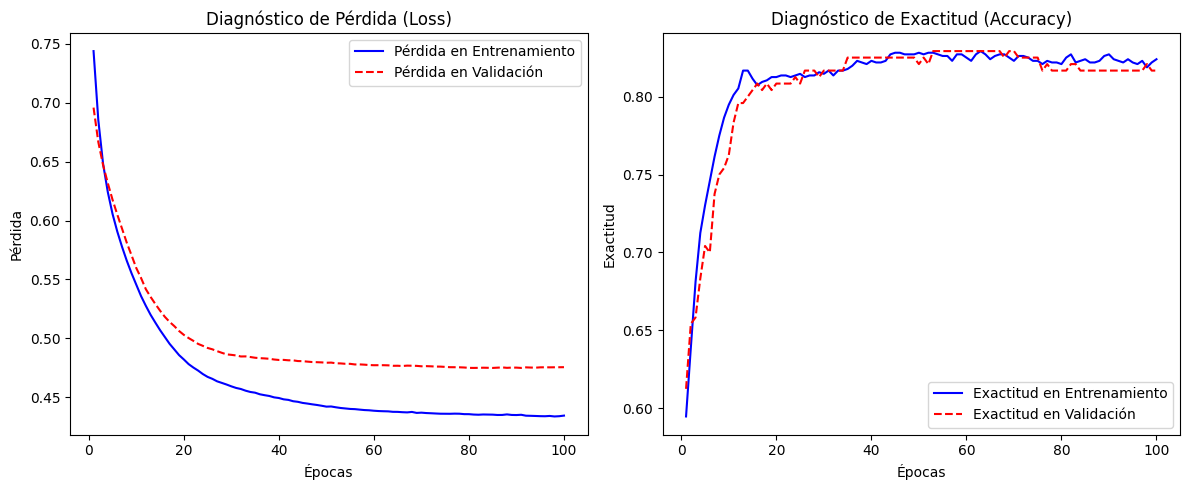

In [42]:
import matplotlib.pyplot as plt

# 1. Ejecutamos el entrenamiento y guardamos el registro
# El parámetro validation_split aparta un 20% de datos nuevos para probar el modelo en cada época
#history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)

# 2. Extraemos las listas de valores del diccionario interno
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epocas = range(1, len(loss) + 1)

# 3. Configuramos el espacio de trabajo en Matplotlib
plt.figure(figsize=(12, 5))

# 4. Generamos el gráfico de la Función de Pérdida
plt.subplot(1, 2, 1)
plt.plot(epocas, loss, label='Pérdida en Entrenamiento', color='blue')
plt.plot(epocas, val_loss, label='Pérdida en Validación', color='red', linestyle='--')
plt.title('Diagnóstico de Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# 5. Generamos el gráfico de Exactitud
plt.subplot(1, 2, 2)
plt.plot(epocas, accuracy, label='Exactitud en Entrenamiento', color='blue')
plt.plot(epocas, val_accuracy, label='Exactitud en Validación', color='red', linestyle='--')
plt.title('Diagnóstico de Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()

# Ajustamos los márgenes y mostramos en pantalla
plt.tight_layout()
plt.show()

In [49]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import Adam

# ─────────────────────────────────────────
# 1. Definimos la red neuronal
# ─────────────────────────────────────────
class MiRed(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(11, 3),   # Capa oculta: 11 entradas → 3 neuronas
            nn.ReLU(),          # Activación ReLU
            nn.Linear(3, 1),    # Capa de salida: 3 → 1 neurona
            nn.Sigmoid()        # Activación Sigmoid (salida entre 0 y 1)
        )

    def forward(self, x):
        return self.red(x)

model = MiRed()
print(model)  # Equivalente a model.summary()

# ─────────────────────────────────────────
# 2. Definimos loss, optimizador y métricas
#    (equivalente a model.compile)
# ─────────────────────────────────────────
criterion = nn.BCELoss()               # Binary Cross Entropy
optimizer = Adam(model.parameters())   # Adam optimizer

# ─────────────────────────────────────────
# 3. Preparamos los datos
#    (equivalente al validation_split=0.2)
# ─────────────────────────────────────────
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

dataset    = TensorDataset(X_tensor, y_tensor)
val_size   = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=10)

# ─────────────────────────────────────────
# 4. Entrenamiento
#    (equivalente a model.fit)
# ─────────────────────────────────────────
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(100):  # 100 épocas

    # ── Fase de entrenamiento ──
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()           # Limpiamos gradientes
        y_pred = model(X_batch)         # Forward pass
        loss   = criterion(y_pred, y_batch)
        loss.backward()                 # Backpropagation
        optimizer.step()                # Actualización de pesos

        train_loss    += loss.item() * len(X_batch)
        train_correct += ((y_pred >= 0.5) == y_batch).sum().item()
        train_total   += len(X_batch)

    # ── Fase de validación ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred  = model(X_batch)
            loss    = criterion(y_pred, y_batch)
            val_loss    += loss.item() * len(X_batch)
            val_correct += ((y_pred >= 0.5) == y_batch).sum().item()
            val_total   += len(X_batch)

    # ── Guardamos métricas ──
    history['loss'].append(train_loss / train_total)
    history['accuracy'].append(train_correct / train_total)
    history['val_loss'].append(val_loss / val_total)
    history['val_accuracy'].append(val_correct / val_total)

    print(f"Época {epoch+1}/100 | "
          f"Loss: {history['loss'][-1]:.4f} | Acc: {history['accuracy'][-1]:.4f} | "
          f"Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_accuracy'][-1]:.4f}")

MiRed(
  (red): Sequential(
    (0): Linear(in_features=11, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


ValueError: could not determine the shape of object type 'DataFrame'

In [31]:
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim
import time

# 1. Crear datos sintéticos (10,000 filas, 11 columnas)
# En MLX los datos ya nacen en la memoria unificada del M4
X = mx.random.normal((10000, 11))
y = mx.random.normal((10000, 1))

# 2. Definir el mismo modelo "pesado" (estilo lista [])
model = nn.Sequential(
    nn.Linear(11, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 1)
)

# 3. Configurar el entrenamiento
def loss_fn(model, X, y):
    return mx.mean(nn.losses.mse_loss(model(X), y))

loss_and_grad_fn = nn.value_and_grad(model, loss_fn)
optimizer = optim.Adam(learning_rate=0.01)

# --- INICIO DEL TEST ---
print("🚀 Entrenando en MLX (Optimizado para M4)...")

# Forzamos una compilación inicial para que la medición sea justa
mx.eval(model.parameters())

start_time = time.time()

for epoch in range(200):
    # Calculamos pérdida y gradientes
    loss, grads = loss_and_grad_fn(model, X, y)
    
    # Actualizamos pesos
    optimizer.update(model, grads)
    
    # ¡CRUCIAL! mx.eval es lo que le dice al M4: "ejecuta esto ahora mismo"
    # Sin esto, MLX solo acumularía tareas sin hacerlas (Lazy Evaluation)
    mx.eval(model.parameters(), optimizer.state)

end_time = time.time()
tiempo_mlx = end_time - start_time

print(f"✅ MLX tardó: {tiempo_mlx:.2f} segundos")

🚀 Entrenando en MLX (Optimizado para M4)...
✅ MLX tardó: 3.04 segundos
